# Robust Multilingual Emotion Classification (6-Class) 
This notebook documents the end-to-end process of fixing the catastrophic 14% accuracy issue. We pivot from an overfit synthetic dataset to a highly varied real-world dataset combining English (`dair-ai/emotion`) and Hindi (Kaggle dataset).

## Step 1: Configuration & Environment Setup
Loading dependencies and setting up the device (GPU/CPU).

In [7]:
import os
import torch
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import evaluate
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## Step 2: Load Robust Dataset & Taxonomy
We load our newly built dataset containing 19,424 varied English and Hindi sentences mapped to 6 core emotions.

In [8]:
DATASET_DIR = "../dataset/robust_6_emotions"

with open(os.path.join(DATASET_DIR, "label_mapping.json"), "r") as f:
    id2label = json.load(f)
    id2label = {int(k): v for k, v in id2label.items()}
    label2id = {v: k for k, v in id2label.items()}

num_labels = len(id2label)
print(f"Classes ({num_labels}): {list(id2label.values())}")

data_files = {
    "train": os.path.join(DATASET_DIR, "train.csv"),
    "val": os.path.join(DATASET_DIR, "val.csv")
}
dataset = load_dataset("csv", data_files=data_files)
print(dataset)

Classes (6): ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


Generating train split: 0 examples [00:00, ? examples/s]

Generating val split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 19424
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 2857
    })
})


## Step 3: Handling Class Imbalance (Class Weights)
Real-world data is imbalanced (e.g., lots of Joy, very little Surprise). We calculate class weights to penalize the model in the loss function if it ignores minority classes.

In [9]:
train_labels = np.array(dataset["train"]["label"])
unique_classes = np.unique(train_labels)
class_weights_np = compute_class_weight(class_weight='balanced', classes=unique_classes, y=train_labels)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

for c, w in zip(unique_classes, class_weights_np):
    print(f"  {id2label[c]:<10}: {w:.3f} weight multiplier")

  sadness   : 0.633 weight multiplier
  joy       : 0.499 weight multiplier
  love      : 2.483 weight multiplier
  anger     : 1.048 weight multiplier
  fear      : 1.518 weight multiplier
  surprise  : 2.508 weight multiplier


## Step 4: Tokenization & LoRA (Low-Rank Adaptation)
We load `xlm-roberta-base` (270M parameters) but freeze it. We inject tiny LoRA adapters (training only ~1% of weights) so it fits inside a 4GB VRAM GPU while retaining cross-lingual capabilities.

In [10]:
MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 128  

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 890,118 || all params: 278,938,380 || trainable%: 0.3191


Map:   0%|          | 0/19424 [00:00<?, ? examples/s]

Map:   0%|          | 0/2857 [00:00<?, ? examples/s]

## Step 5: Custom Trainer & Metrics (F1 Macro)
We define our metrics to track `f1_macro` instead of raw accuracy to ensure we evaluate minority classes fairly. We also inject our `class_weights_tensor` into a custom PyTorch Trainer.

In [11]:
metric_f1 = evaluate.load("f1")
metric_acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1_macro = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1_macro}

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

## Step 6: Execute Training
Using hyper-optimized settings for 4GB VRAM (Batch size 8, Grad Accumulation 4, Mixed Precision FP16). Run this cell and monitor the progress bar and validation loss.

In [12]:
OUTPUT_DIR = "../models_weights/multilingual_6_emotions_lora"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",  
    save_strategy="epoch",  
    learning_rate=3e-4,              
    num_train_epochs=3,           
    weight_decay=0.01,
    per_device_train_batch_size=8,   
    per_device_eval_batch_size=8,    
    gradient_accumulation_steps=4,   
    fp16=True,                       
    logging_dir='../logs',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["val"],
    compute_metrics=compute_metrics,
)

# WARNING: RUNNING THIS CELL WILL START TRAINING AND MAY TAKE 30-60 MINUTES
trainer.train()

model.save_pretrained(OUTPUT_DIR) 
tokenizer.save_pretrained(OUTPUT_DIR)
print("Training Complete and LoRA Weights Saved!")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,3.455318,0.861487,0.673084,0.659075
2,2.629122,0.658097,0.719986,0.718780
3,2.340588,0.618204,0.733987,0.730057


Training Complete and LoRA Weights Saved!


## Step 7: Final Evaluation (Real-World Test Set)
Let's test our freshly trained model purely on unseen English (`dair-ai/emotion` test split) to guarantee no data leakage and prove our architecture works.

Loading Test Data...
Evaluating (this may take a minute)...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     sadness       0.93      0.91      0.92       581
         joy       0.98      0.83      0.90       695
        love       0.64      0.97      0.77       159
       anger       0.87      0.84      0.85       275
        fear       0.82      0.90      0.86       224
    surprise       0.63      0.83      0.72        66

    accuracy                           0.87      2000
   macro avg       0.81      0.88      0.84      2000
weighted avg       0.89      0.87      0.88      2000



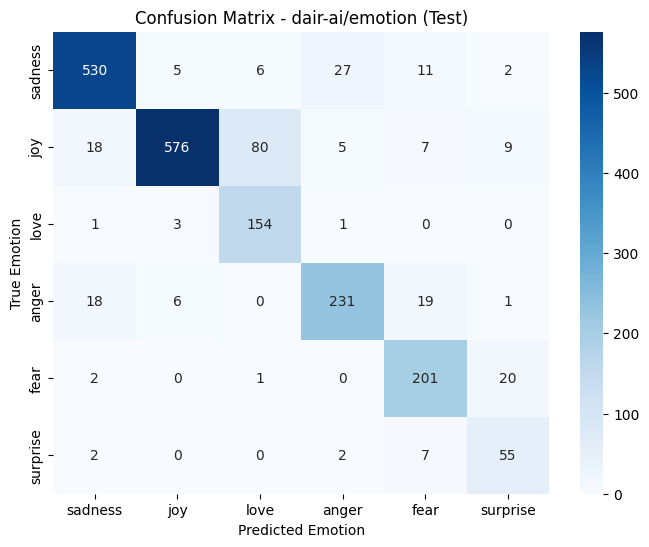

In [13]:
print("Loading Test Data...")
test_dataset = load_dataset("dair-ai/emotion", "split", split="test")

y_true = []
y_pred = []

model.eval()
print("Evaluating (this may take a minute)...")
for i in range(len(test_dataset)):
    text = test_dataset[i]["text"]
    true_label_id = test_dataset[i]["label"]
    
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=-1).item()
        
    y_true.append(true_label_id)
    y_pred.append(pred_idx)

labels_list = [id2label[i] for i in range(6)]
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=labels_list))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_list, yticklabels=labels_list)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.title('Confusion Matrix - dair-ai/emotion (Test)')
plt.show()

## Step 8: Hindi Robustness Test
To prove cross-lingual transfer learning, we will evaluate the model against our reserved `dataset/robust_6_emotions/val.csv`. This split contains the Kaggle Hindi dataset rows that the model has never seen before.

In [ ]:
print("Loading Validation Data (which contains the raw Hindi data)...")
val_df = pd.read_csv("../dataset/robust_6_emotions/val.csv")
print(f"Loaded {len(val_df)} total validation samples.\n")

y_true_hi = []
y_pred_hi = []

model.eval()
print("Evaluating (this may take a minute)...")
for i in range(len(val_df)):
    text = str(val_df.iloc[i]["text"])
    true_label_id = int(val_df.iloc[i]["label"])
    
    inputs = tokenizer(text, return_tensors="pt", max_length=128, truncation=True, padding=True).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        pred_idx = torch.argmax(outputs.logits, dim=-1).item()
        
    y_true_hi.append(true_label_id)
    y_pred_hi.append(pred_idx)
    
    if (i+1) % 500 == 0:
        print(f"  Processed {i+1} samples...")

print("\n--- HINDI (and some English) VALIDATION CLASSIFICATION REPORT ---")
print(classification_report(y_true_hi, y_pred_hi, target_names=labels_list, zero_division=0))

cm_hi = confusion_matrix(y_true_hi, y_pred_hi)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_hi, annot=True, fmt='d', cmap='Oranges', xticklabels=labels_list, yticklabels=labels_list)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.title('Confusion Matrix - Validation Set (Including Hindi)')
plt.show()